Saving sample_be_sales.xlsx to sample_be_sales (3).xlsx
User uploaded file "sample_be_sales (3).xlsx" with length 12172 bytes
===== SALES DATASET ====
0 order_id                 date product_id product_name  Price  Quantity
0        1  2021-01-01 00:00:00          7        Mango     51         4
1        2  2021-01-01 00:00:00          9    Pineapple     55        10
2        3  2021-01-01 00:00:00          2      Avocado     33         4
3        4  2021-01-02 00:00:00         10   Watermelon     35         4
4        5  2021-01-03 00:00:00          3       Banana     39         7

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   order_id      100 non-null    object
 1   date          100 non-null    object
 2   product_id    100 non-null    object
 3   product_name  100 non-null    object
 4   Price         100 non-null    

/tmp/ipykernel_2312/719416046.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price'].fillna(0, inplace=True)
/tmp/ipykernel_2312/719416046.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.met

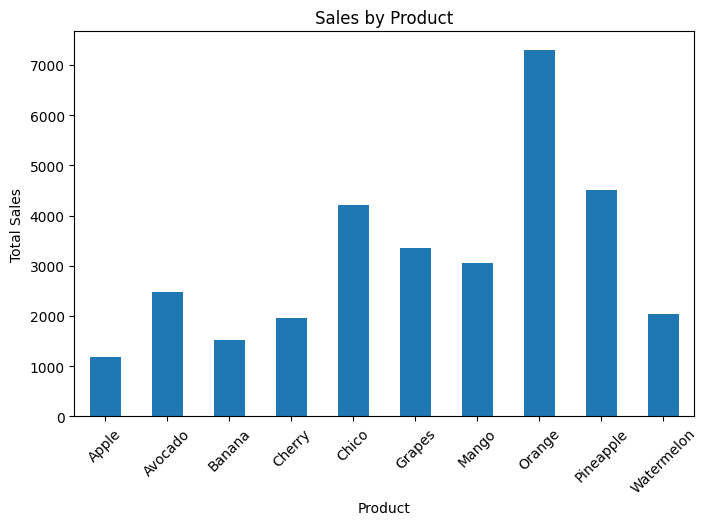

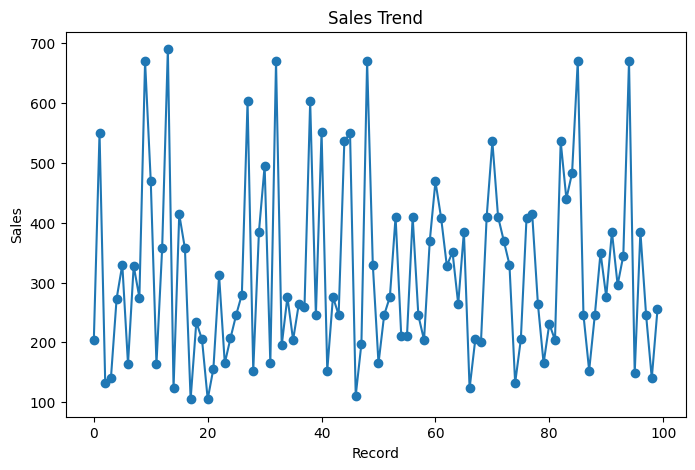

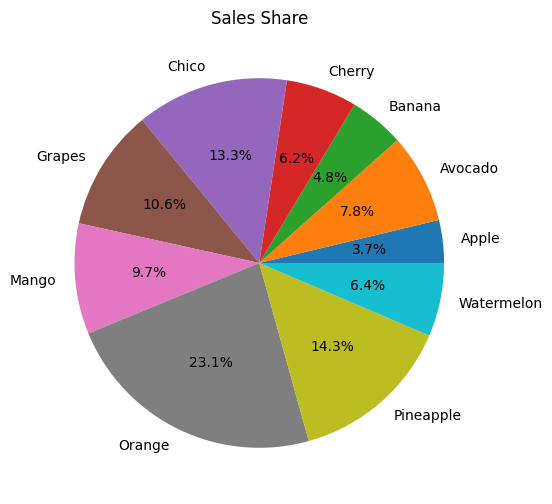

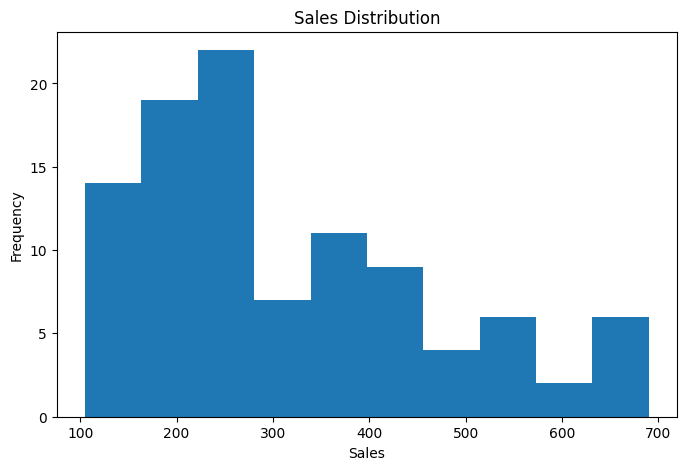

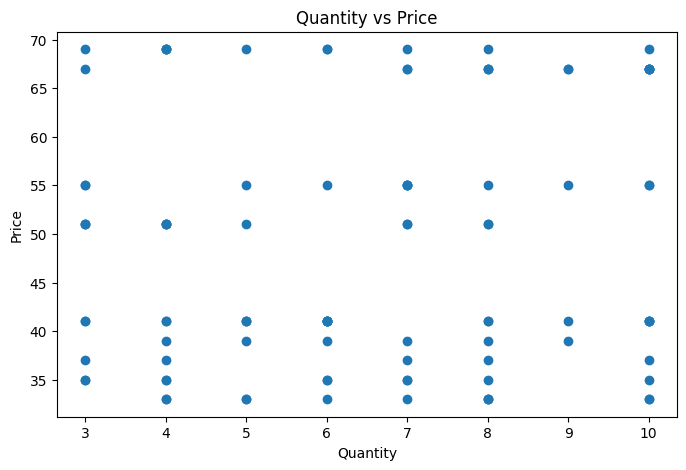

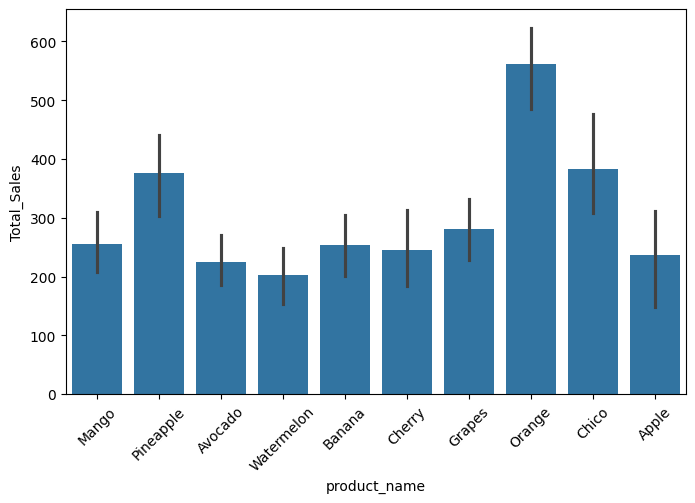

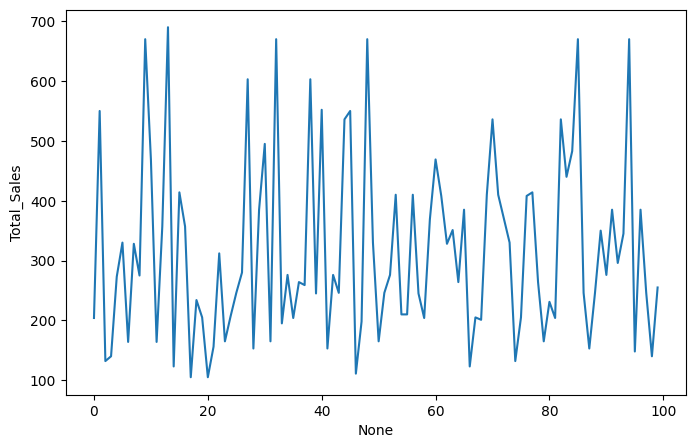

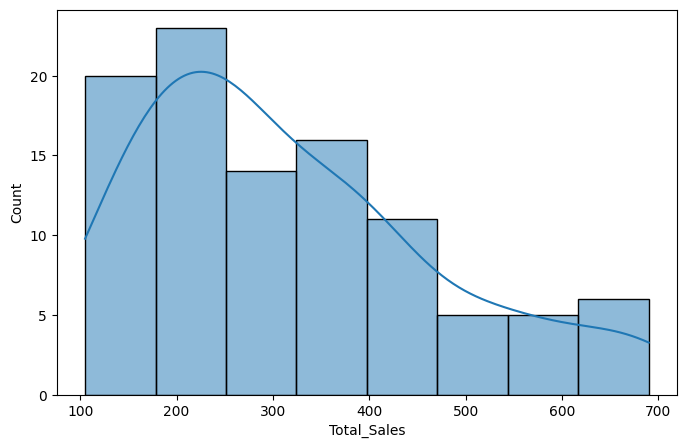

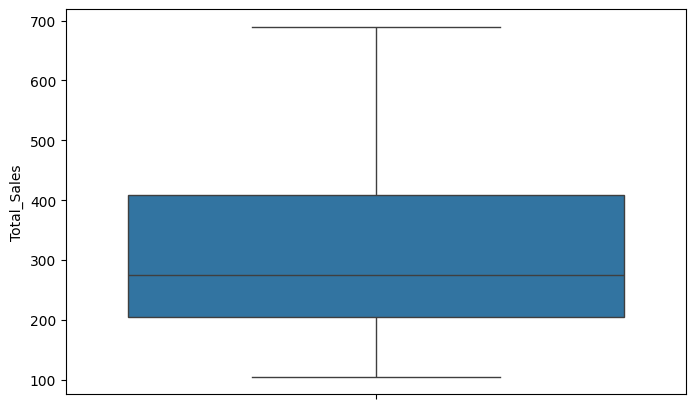

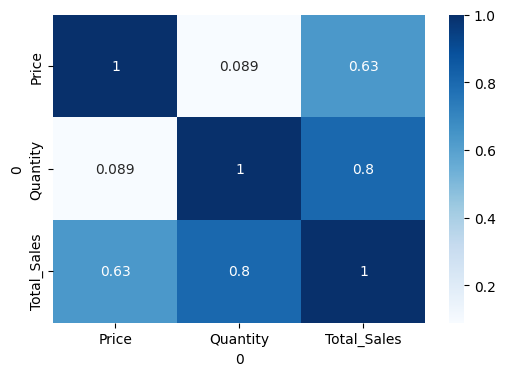


Sales Data Analysis Completed Successfully!


In [ ]:
# ===========================================
# SALES DATA ANALYSIS USING PYTHON
# Libraries: NumPy, Pandas, Matplotlib, Seaborn
# ===========================================

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

# Read Excel File - specifying header=3 to correctly identify column names
df = pd.read_excel('sample_be_sales.xlsx', header=3)

# Based on the previous output, even with header=3, the columns were 'Unnamed: X',
# and the intended headers ('order_id', 'date', etc.) appeared as the first row of data.
# So, we explicitly set the columns from the first row and drop that row.
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

# Rename columns to 'Price' and 'Quantity' for consistency with calculation logic
df = df.rename(columns={'price_per_kg': 'Price', 'weight_kg': 'Quantity'})

# Convert 'Price' and 'Quantity' columns to numeric type, coercing errors to NaN
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

# Fill NaN values that might have resulted from coercion (e.g., with 0)
df['Price'].fillna(0, inplace=True)
df['Quantity'].fillna(0, inplace=True)

print("===== SALES DATASET ====")
print(df.head())

# -------------------------------------------
# Pandas Functions
# -------------------------------------------
print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Values")
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# -------------------------------------------
# If Total_Sales column doesn't exist
# -------------------------------------------
# This block will now correctly execute as 'Quantity' and 'Price' columns are present
if 'Total_Sales' not in df.columns:
    if 'Quantity' in df.columns and 'Price' in df.columns:
        df['Total_Sales'] = df['Quantity'] * df['Price']

# Ensure Total_Sales is numeric, in case any oddities slipped through before groupby
df['Total_Sales'] = pd.to_numeric(df['Total_Sales'], errors='coerce')
df['Total_Sales'].fillna(0, inplace=True)

# -------------------------------------------
# NumPy Functions
# -------------------------------------------
sales = np.array(df['Total_Sales'])

print("\nMean Sales:", np.mean(sales))
print("Maximum Sales:", np.max(sales))
print("Minimum Sales:", np.min(sales))
print("Total Sales:", np.sum(sales))
print("Standard Deviation:", np.std(sales))

# -------------------------------------------
# Group By Product (if Product column exists)
# -------------------------------------------
if 'product_name' in df.columns:
    product_sales = df.groupby('product_name')['Total_Sales'].sum()
    # Ensure product_sales is numeric
    product_sales = pd.to_numeric(product_sales)
    print("\nSales by Product")
    print(product_sales)

# -------------------------------------------
# Matplotlib Charts
# -------------------------------------------

# Bar Chart
if 'product_name' in df.columns:
    plt.figure(figsize=(8,5))
    product_sales.plot(kind='bar')
    plt.title("Sales by Product")
    plt.xlabel("Product")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.show()

# Line Chart
plt.figure(figsize=(8,5))
plt.plot(df['Total_Sales'], marker='o')
plt.title("Sales Trend")
plt.xlabel("Record")
plt.ylabel("Sales")
plt.show()

# Pie Chart
if 'product_name' in df.columns:
    plt.figure(figsize=(6,6))
    product_sales.plot(kind='pie', autopct='%1.1f%%')
    plt.ylabel("")
    plt.title("Sales Share")
    plt.show()

# Histogram
plt.figure(figsize=(8,5))
plt.hist(df['Total_Sales'], bins=10)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# Scatter Plot
if 'Quantity' in df.columns and 'Price' in df.columns:
    plt.figure(figsize=(8,5))
    plt.scatter(df['Quantity'], df['Price'])
    plt.title("Quantity vs Price")
    plt.xlabel("Quantity")
    plt.ylabel("Price")
    plt.show()


# Seaborn Charts

# Bar Plot
if 'product_name' in df.columns:
    plt.figure(figsize=(8,5))
    sns.barplot(x='product_name', y='Total_Sales', data=df)
    plt.xticks(rotation=45)
    plt.show()

# Line Plot
plt.figure(figsize=(8,5))
sns.lineplot(x=df.index, y='Total_Sales', data=df)
plt.show()

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Sales'], kde=True)
plt.show()

# Box Plot
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Total_Sales'])
plt.show()

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='Blues')
plt.show()

print("\nSales Data Analysis Completed Successfully!")